In [2]:
import os
import sqlite3
import numpy as np
import pandas as pd
import vectorbt as vbt
import quantstats as qs
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")


# 解决画图中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


class VectorbtRotationStrategy:
    """
    基于 VectorBT 的 ETF 因子轮动回测框架
    支持多标的横向轮动、自定义因子、真实手续费与资金流转
    """
    def __init__(self, db_path, code_dict, safe_asset_code=None, benchmark_code='510300', start_date='20150101', end_date='20260101'):
        self.db_path = db_path
        self.code_dict = code_dict
        self.code_list = list(code_dict.keys())
        self.safe_asset_code = safe_asset_code
        self.benchmark_code = benchmark_code
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        
        # 存放原始数据的容器
        self.prices = None 
        self.highs = None
        self.lows = None
        
        # 初始化加载数据
        self._load_data()

    def _load_data(self):
        """从 SQLite 数据库提取数据并转为 vectorbt 最喜欢的宽表 (Wide DataFrame)"""
        print("📥 正在从本地数据库加载数据...")
        conn = sqlite3.connect(self.db_path)
        df_close_list, df_high_list, df_low_list = [], [], []
        
        # 确定需要加载的所有标的（风险资产池 + 单独指定的避险资产）
        all_codes = self.code_list.copy()
        if self.safe_asset_code and self.safe_asset_code not in all_codes:
            all_codes.append(self.safe_asset_code)
            
        for code in all_codes:
            try:
                query = f'SELECT 日期, 最高, 最低, 收盘 FROM "{code}"'
                df = pd.read_sql(query, conn)
                df['日期'] = pd.to_datetime(df['日期'])
                df = df[(df['日期'] >= self.start_date) & (df['日期'] <= self.end_date)]
                
                df = df.set_index('日期')
                
                # 分别存放收盘、最高、最低
                df_close_list.append(df[['收盘']].rename(columns={'收盘': code}))
                df_high_list.append(df[['最高']].rename(columns={'最高': code}))
                df_low_list.append(df[['最低']].rename(columns={'最低': code}))
                
            except Exception as e:
                print(f"⚠️ 读取 {code} 失败: {e}")
                
        conn.close()
        
        # 合并所有标的，采用外连接保证日期对齐，前向填充缺失值
        self.prices = pd.concat(df_close_list, axis=1).sort_index().ffill()
        self.highs = pd.concat(df_high_list, axis=1).sort_index().ffill()
        self.lows = pd.concat(df_low_list, axis=1).sort_index().ffill()
        print(f"✅ 数据加载完成，形状: {self.prices.shape}")


    # ==================== 因子库 ====================
    
    def factor_pure_momentum(self, window=20):
        """简单因子：计算过去 N 天的动量涨幅"""
        print(f"🧮 计算因子: {window}日纯动量...")
        # 仅针对风险资产计算因子
        risk_prices = self.prices[self.code_list]
        factor_df = risk_prices / risk_prices.shift(window) - 1.0
        return factor_df

    def factor_atr_dynamic_score(self, lb_min=20, lb_max=60, vol_short_len=20, vol_long_len=60, ratio_cap=0.9):
        """复杂因子：基于真实 ATR 计算动态回溯窗口得分"""
        print(f"🧮 计算因子: 基于真实ATR的动态窗口回归得分...")
        
        # 仅针对风险资产计算因子
        risk_prices = self.prices[self.code_list]
        risk_highs = self.highs[self.code_list]
        risk_lows = self.lows[self.code_list]
        
        # 计算 True Range (TR) 和 ATR
        prev_close = risk_prices.shift(1)
        
        tr1 = risk_highs - risk_lows
        tr2 = (risk_highs - prev_close).abs()
        tr3 = (risk_lows - prev_close).abs()
        
        # 取三者的最大值为当天的 TR
        tr = pd.DataFrame(
            np.maximum(tr1.values, np.maximum(tr2.values, tr3.values)),
            index=risk_prices.index,
            columns=risk_prices.columns
        )
        
        # 计算短长周期的 ATR
        atr_short = tr.rolling(vol_short_len).mean()
        atr_long = tr.rolling(vol_long_len).mean()
        
        # 计算动态窗口大小 
        vol_ratio = atr_short / atr_long
        vol_ratio_capped = vol_ratio.clip(upper=ratio_cap)
        lookback_df = np.floor(lb_min + (lb_max - lb_min) * (1 - vol_ratio_capped)).fillna(lb_max).astype(int)
        
        # 准备因子矩阵
        factor_df = pd.DataFrame(np.nan, index=risk_prices.index, columns=self.code_list)
        
        # 纯 Numpy 加速的得分计算函数
        def fast_score(y):
            if len(y) < 2 or y[0] == 0: return np.nan
            y_norm = y / y[0]
            x = np.arange(1, len(y) + 1)
            # 最小二乘法斜率和R2
            cov = np.cov(x, y_norm, ddof=0)[0, 1]
            var_x = np.var(x, ddof=0)
            if var_x == 0: return np.nan
            slope = cov / var_x
            r_squared = np.corrcoef(x, y_norm)[0, 1] ** 2
            return 10000 * slope * r_squared
            
        # 滚动计算得分
        for code in self.code_list:
            prices_arr = risk_prices[code].values
            lookback_arr = lookback_df[code].values
            scores = np.full(len(prices_arr), np.nan)
            
            for i in range(lb_max, len(prices_arr)):
                curr_lb = lookback_arr[i]
                window_prices = prices_arr[i - curr_lb + 1 : i + 1]
                scores[i] = fast_score(window_prices)
                
            factor_df[code] = scores
            
        return factor_df

    def factor_trend_score(self, window=25):
        """
        中阶因子：基于线性回归斜率和决定系数 R2 的趋势得分
        得分 = 归一化后收盘价的斜率 * R2
        """
        print(f"🧮 计算因子: {window}日线性回归趋势得分 (Slope * R2)...")
        
        # 仅针对风险资产计算因子
        risk_prices = self.prices[self.code_list]
        
        # 1. 构造全局递增的时间序列索引作为 X 轴
        # 只要保证 X 是等差数列，其与 Y 的协方差/相关系数的计算性质与 [1,2,..,N] 完全一致
        idx = pd.Series(np.arange(len(risk_prices)), index=risk_prices.index)
        
        # 2. 计算滚动协方差和相关系数 (Pandas C 引擎底层运算，极快)
        # rolling().cov() 和 corr() 会自动与传入的 Series 对齐并进行广播计算
        rolling_cov = risk_prices.rolling(window).cov(idx)
        rolling_corr = risk_prices.rolling(window).corr(idx)
        
        # 3. 计算 X 的样本方差 (ddof=1)
        # 固定长度为 window 的等差数列 [1,2,..,N] 的样本方差公式为恒定常数：
        var_x = window * (window + 1) / 12  
        
        # 4. 计算原始斜率和 R2
        slope_raw = rolling_cov / var_x
        r_squared = rolling_corr ** 2
        
        # 5. 数学等价转换：
        # 获取每个窗口的起始价格 P0 (即向前 shift window - 1 天)
        p0 = risk_prices.shift(window - 1) 
        
        # 归一化后的斜率 = 原始斜率 / P0
        slope_norm = slope_raw / p0
        
        # 6. 计算最终得分 (避免除以 0 产生的无穷大)
        factor_df = (slope_norm * r_squared).replace([np.inf, -np.inf], np.nan)
        
        return factor_df

    def factor_rsrs(self, window=18):
        """
        标准 RSRS 因子 (Resistance Support Relative Strength)
        计算过去 N 天最高价对最低价的回归斜率 (Slope) 及其 R2 增强得分
        """
        print(f"🧮 计算因子: {window}日 RSRS 阻力支撑强弱指标...")
        
        # 仅针对风险资产获取最高价和最低价矩阵
        highs = self.highs[self.code_list]
        lows = self.lows[self.code_list]
        
        # ==========================================
        # 利用数学公式展开进行极速滚动回归 (纯向量化)
        # X = Lows (自变量), Y = Highs (因变量)
        # ==========================================
        
        # 计算滚动期望 E[X], E[Y]
        mean_x = lows.rolling(window).mean()
        mean_y = highs.rolling(window).mean()
        
        # 计算滚动期望 E[XY]
        mean_xy = (lows * highs).rolling(window).mean()
        
        # 计算滚动期望 E[X^2], E[Y^2]
        mean_x2 = (lows ** 2).rolling(window).mean()
        mean_y2 = (highs ** 2).rolling(window).mean()
        
        # 计算协方差 Cov(X,Y) = E[XY] - E[X]E[Y]
        cov_xy = mean_xy - mean_x * mean_y
        
        # 计算方差 Var(X) = E[X^2] - (E[X])^2
        var_x = mean_x2 - mean_x ** 2
        var_y = mean_y2 - mean_y ** 2
        
        # 避免除以 0 导致无穷大，将 0 替换为 NaN
        var_x = var_x.replace(0, np.nan)
        var_y = var_y.replace(0, np.nan)
        
        # 1. 计算斜率 Slope (即原始的 RSRS 值)
        slope = cov_xy / var_x
        
        # 2. 计算决定系数 R^2 = Cov(X,Y)^2 / (Var(X) * Var(Y))
        r_squared = (cov_xy ** 2) / (var_x * var_y)
        
        # 3. 计算增强版得分 (Slope * R^2)
        rsrs_score = slope * r_squared
        
        return rsrs_score
    
    def factor_rsrs_advanced(self, window=16, z_window=300):
        """
        高级 RSRS 因子 (Right-Skewed Standard Score)
        融合了标准分 (Z-Score)、决定系数 (R2) 和斜率 (Beta) 的终极优化版本。
        
        参数:
        window: int, 计算线性回归的窗口期 N (研报右偏版本推荐 16)
        z_window: int, 计算标准分(Z-Score)的滚动观察期 M (研报右偏版本推荐 300)
        """
        print(f"🧮 计算因子: {window}日 RSRS 右偏标准分 (Z观察期: {z_window}日)...")
        
        # 仅针对风险资产获取最高价和最低价矩阵
        highs = self.highs[self.code_list]
        lows = self.lows[self.code_list]
        
        # ==========================================
        # 1. 极速计算斜率 (Beta) 和 决定系数 (R2)
        # ==========================================
        mean_x = lows.rolling(window).mean()
        mean_y = highs.rolling(window).mean()
        mean_xy = (lows * highs).rolling(window).mean()
        mean_x2 = (lows ** 2).rolling(window).mean()
        mean_y2 = (highs ** 2).rolling(window).mean()
        
        cov_xy = mean_xy - mean_x * mean_y
        var_x = mean_x2 - mean_x ** 2
        var_y = mean_y2 - mean_y ** 2
        
        # 避免除以 0
        var_x = var_x.replace(0, np.nan)
        var_y = var_y.replace(0, np.nan)
        
        # 计算 Beta (斜率) 和 R2
        beta = cov_xy / var_x
        r_squared = (cov_xy ** 2) / (var_x * var_y)
        
        # ==========================================
        # 2. 计算标准分 (Z-Score)
        # 公式: (当前Beta - 滚动均值) / 滚动标准差
        # ==========================================
        # 按照研报逻辑，前期数据不足 M 时，最少使用 20 天的数据计算
        beta_mean = beta.rolling(z_window, min_periods=20).mean()
        beta_std = beta.rolling(z_window, min_periods=20).std()
        
        beta_std = beta_std.replace(0, np.nan) # 防止除零溢出
        std_score = (beta - beta_mean) / beta_std
        
        # ==========================================
        # 3. 计算修正标准分 (Modified Z-Score)
        # 公式: R2 * 标准分
        # ==========================================
        mdf_std_score = r_squared * std_score
        
        # ==========================================
        # 4. 计算右偏标准分 (Right-Skewed Z-Score)
        # 公式: Beta * 修正标准分
        # ==========================================
        rsk_std_score = beta * mdf_std_score
        
        # 最终返回研报优选的右偏标准分因子矩阵
        return rsk_std_score
    
    # ==================== 过滤器插件 (Filters) ====================
    
    def filter_recent_drop(self, max_drop_pct=0.05):
        """
        插件：过滤近期出现大幅下跌或连续下跌的ETF
        参数:
            - max_drop_pct: float, 最大允许下跌幅度（例如 0.05 代表 5%）
        返回: pd.DataFrame (bool)。True表示安全(可交易)，False表示危险(需过滤)
        """
        # 将跌幅百分比转换为价格比率阈值
        # 例如 0.05 转换为 0.95
        drop_threshold = 1.0 - max_drop_pct
        
        print(f"🛡️ 计算过滤器: 近期下跌过滤 (最大允许跌幅: {max_drop_pct*100}%)")
        
        # 仅针对风险资产计算
        prices = self.prices[self.code_list]
        
        # 计算单日涨跌幅
        daily_ret = prices / prices.shift(1)
        
        # 条件1：近3天内有任意一天跌幅超过 max_drop_pct
        is_large_drop = daily_ret < drop_threshold
        con1 = is_large_drop.rolling(window=3).max().fillna(0).astype(bool)
        
        # 条件2：连续3天连跌，且3天累计跌幅超过 max_drop_pct
        is_down = prices < prices.shift(1)
        three_down = is_down & is_down.shift(1) & is_down.shift(2)
        three_day_drop = (prices / prices.shift(3)) < drop_threshold
        con2 = three_down & three_day_drop
        
        # 条件3：昨天触发了条件2 (连续3天连跌且累计跌幅过大)
        con3 = con2.shift(1).fillna(False)
        
        # 综合危险信号：满足以上任意一个，即视为危险 (True)
        is_danger = con1 | con2 | con3
        
        # 返回安全白名单 (取反)
        return ~is_danger

    def filter_rsrs_timing(self, window=16, z_window=300, threshold=-0.7):
        """
        ✨ 新增插件：RSRS 右偏标准分择时风控
        当某资产的 RSRS 分数跌破 threshold（通常为-0.7左右），视为趋势破位，取消其配置资格。
        """
        print(f"🛡️ 启动风控插件: RSRS 高级右偏标准分 (阈值: {threshold})")
        # 调用内部方法计算 RSRS 矩阵
        rsrs_matrix = self.factor_rsrs_advanced(window=window, z_window=z_window)
        
        # 产生布尔掩码：大于阈值才是 True (安全)，小于等于阈值为 False (危险)
        # 研报标准：大于0.7强烈看多，小于-0.7强烈看空。这里我们把 -0.7 作为清仓离场线
        is_safe_mask = rsrs_matrix >= threshold
        
        return is_safe_mask
    
    # ==================== 信号与执行 ====================

    def generate_target_weights(self, factor_df, top_n=1, enable_absolute_momentum=False, absolute_threshold=0.0, filter_mask=None):
        """
        根据因子值生成目标权重矩阵。
        参数:
            - factor_df: DataFrame，包含所有风险资产的因子得分
            - top_n: int，选择因子得分排名前 N 的资产进行投资
            - enable_absolute_momentum: bool，是否启用绝对动量过滤
            - absolute_threshold: float，绝对动量的得分阈值，低于此值的资产将被没收权重
            - filter_mask: DataFrame (bool)，外部过滤器插件的结果，True表示安全，False表示危险。被标记为False的资产将被剔除（权重设为0）。
        """
        print(f"🎯 正在根据因子生成目标权重 (Top {top_n})...")
        
        # --- 🔌 插件过滤逻辑 (前置拦截) ---
        if filter_mask is not None:
            print("🧩 已接入外部过滤器插件，正在剔除高风险标的...")
            # 将 filter_mask 中为 False (危险) 的位置，在 factor_df 中设为 NaN
            # 被设为 NaN 的资产将无法参与下方的 Top N 竞争
            factor_df = factor_df.where(filter_mask, np.nan)
            
        # 1. 获取所有参与排名的风险资产
        risk_assets = list(factor_df.columns)
        
        # 2. 横向竞争（相对动量）：在风险资产中评出 Top N
        ranks = factor_df.rank(axis=1, ascending=False)
        mask_top = ranks <= top_n
        
        # 初始化风险资产的权重
        risk_weights = pd.DataFrame(0.0, index=factor_df.index, columns=risk_assets)
        risk_weights[mask_top] = 1.0 / top_n
        
        final_risk_weights = risk_weights.copy()
        
        # 3. 纵向过滤（绝对动量逻辑）
        if enable_absolute_momentum:
            print(f"🔒 绝对动量已开启 (阈值: {absolute_threshold})")
            # 得分必须大于阈值，否则没收权重变回 0.0
            pass_filter = factor_df > absolute_threshold
            final_risk_weights = risk_weights[pass_filter].fillna(0.0)
        else:
            print("🔓 绝对动量已关闭，仅使用相对排名分配权重")
            
        # 4. 计算剩余未分配的权重 (被没收的，或原来就不足的)
        remaining_weights = (1.0 - final_risk_weights.sum(axis=1)).round(4)
        
        # 5. 拼合最终的权重矩阵 (确保包含底仓价格矩阵中的所有列，包括避险资产)
        target_weights = pd.DataFrame(0.0, index=factor_df.index, columns=self.prices.columns)
        
        # 赋予风险资产权重
        target_weights[risk_assets] = final_risk_weights
        
        # 赋予避险资产权重
        if self.safe_asset_code and self.safe_asset_code in self.prices.columns:
            target_weights[self.safe_asset_code] = remaining_weights
        elif self.safe_asset_code:
            print(f"⚠️ 警告: 指定了避险资产 '{self.safe_asset_code}' 但数据读取失败，退化为【空仓】(持有现金)。")
        
        return target_weights

    def run_backtest(self, target_weights, init_cash=100000, fees=0.0001):
        """核心回测引擎"""
        print(f"🚀 开始撮合回测 (初始资金: {init_cash}, 费率: {fees})...")

        # exec_weights = target_weights.shift(1).fillna(0.0)  # T-1 生成信号，T 日执行
        
        pf = vbt.Portfolio.from_orders(
            close=self.prices,
            size=target_weights,
            size_type='targetpercent',
            group_by=True,          
            cash_sharing=True,      
            init_cash=init_cash,
            fees=fees,
            slippage=0.000,         
            freq='D'                
        )
        print("✅ 回测完成！")
        return pf

📥 正在从本地数据库加载数据...
✅ 数据加载完成，形状: (2430, 7)
🧮 计算因子: 20日纯动量...
🛡️ 计算过滤器: 近期下跌过滤 (最大允许跌幅: 5.0%)
🎯 正在根据因子生成目标权重 (Top 1)...
🧩 已接入外部过滤器插件，正在剔除高风险标的...
🔓 绝对动量已关闭，仅使用相对排名分配权重
🚀 开始撮合回测 (初始资金: 100000, 费率: 6e-05)...
✅ 回测完成！

📝 正在生成 QuantStats HTML 报告...


                    Benchmark    Strategy
------------------  -----------  ----------
Start Period        2016-01-05   2016-01-05
End Period          2025-12-31   2025-12-31
Risk-Free Rate      0.0%         0.0%
Time in Market      98.0%        98.0%

Cumulative Return   506.37%      1,195.44%
CAGR﹪              13.26%       19.36%

Sharpe              0.95         1.19
Prob. Sharpe Ratio  99.82%       99.99%
Sortino             1.36         1.92
Sortino/√2          0.96         1.36
Omega               1.27         1.27

Max Drawdown        -28.57%      -22.72%
Longest DD Days     569          291

Gain/Pain Ratio     0.19         0.27
Gain/Pain (1M)      1.21         1.87

Payoff Ratio        0.97         1.13
Profit Factor       1.19         1.27
Common Sense Ratio  1.3          1.45
CPC Index           0.62         0.7
Tail Ratio          1.09         1.14
Outlier Win Ratio   4.08         3.59
Outlier Loss Ratio  3.91         4.5

MTD                 -2.01%       -3.19%
3M         

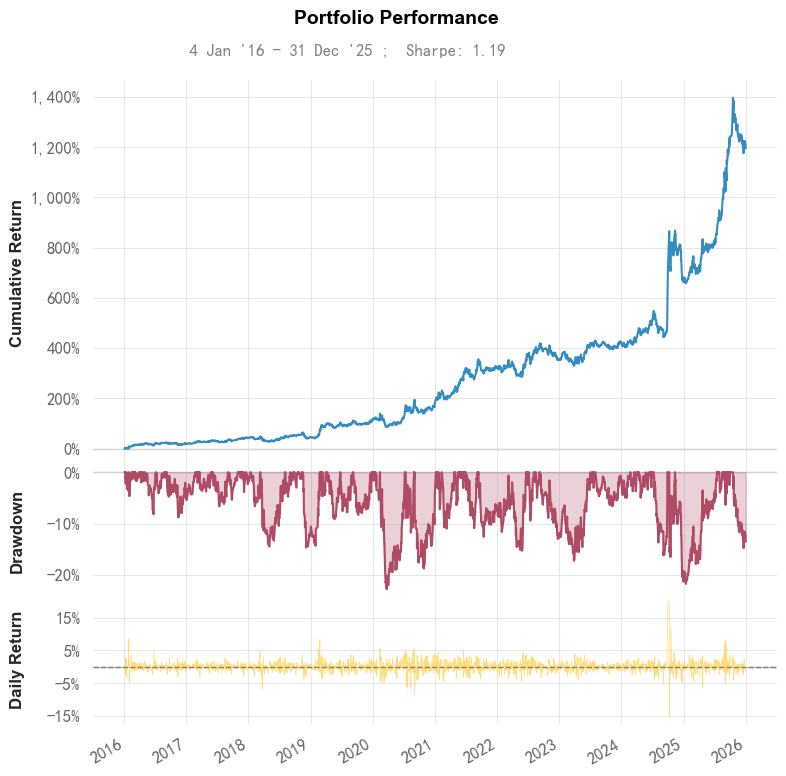

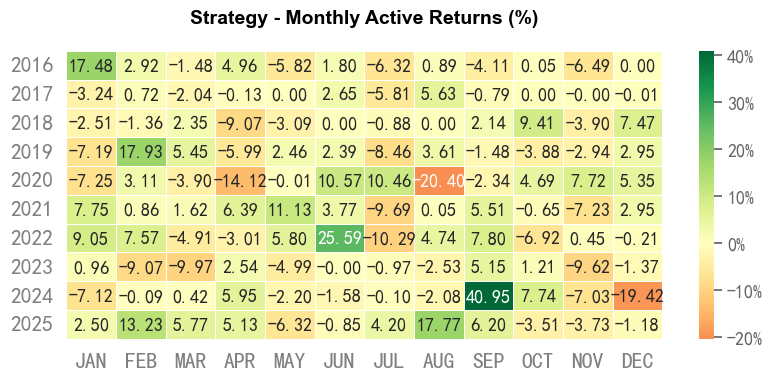

In [6]:

# ================= 运行入口与分析 =================
if __name__ == "__main__":
    
    # 1. 配置参数 (请确保路径对齐你的项目结构)
    DB_PATH = '../database/dayK.db'
    
    # 💡纯净的字典：只存放参与横向打分排名的风险资产
    ETF_DICT = {
        # '510300': '沪深300ETF华泰柏瑞',
        # '510500': '中证500ETF',
        # '510880': '红利ETF华泰柏瑞',
        # '159915': '创业板ETF易方达',
        '513100': '纳指ETF',
        '518880': '黄金ETF华安',
        '512890': '红利低波ETF华泰柏瑞',
        '588000': '科创50ETF',
        '159949': '创业板50ETF华安',
        '563300': '中证2000ETF华泰柏瑞',
        # '159985': '豆粕ETF',
    }
    BENCHMARK_CODE = '513100'
    
    # 单独拿出来定义，不混杂在 ETF_DICT 中
    SAFE_ASSET_CODE = '161119' # 可以设为 None 来全局只空仓
    REPORT_TITLE = "ETF Rotation 3Y Drop 0.05"
    
    # 2. 实例化策略框架
    strategy = VectorbtRotationStrategy(
        db_path=DB_PATH,
        code_dict=ETF_DICT,
        safe_asset_code=SAFE_ASSET_CODE, # 👈 在初始化框架时，以专用通道传入避险资产
        benchmark_code=BENCHMARK_CODE,
        start_date='20160101',  # 10年数据，覆盖多个牛熊周期
        end_date='20260101',
        # start_date='20230301',  # 3年数据，部分ETF上市较晚
        # end_date='20260301',
    )
    
    factor = strategy.factor_pure_momentum(window=20)  # 纯动量因子
    # factor = strategy.factor_atr_dynamic_score()  # ATR 动态窗口得分因子
    # factor = strategy.factor_trend_score(window=20)  # 线性回归趋势得分因子

    # rsrs_safe_mask = strategy.filter_rsrs_timing(window=16, z_window=300, threshold=-0.7)
    drop_safe_mask = strategy.filter_recent_drop(0.05)
    # combined_mask = rsrs_safe_mask & drop_safe_mask

    # 3. 生成目标权重 
    weights_atr = strategy.generate_target_weights(
        factor, 
        top_n=1,  
        # enable_absolute_momentum=True, 
        # absolute_threshold=0,
        filter_mask=drop_safe_mask,        
    )
    
    pf_atr = strategy.run_backtest(weights_atr, init_cash=100000, fees=0.00006)

    # # 4. 输出与可视化
    # print("\n" + "="*40)
    # print("📈 回测基础统计指标")
    # print("="*40)
    # print(pf_atr.stats())
    
    # 5. 结合 QuantStats 输出报告
    print("\n📝 正在生成 QuantStats HTML 报告...")
    strategy_returns = pf_atr.returns()
    benchmark_returns = strategy.prices[BENCHMARK_CODE].pct_change().fillna(0)
    strategy_returns, benchmark_returns = strategy_returns.align(benchmark_returns, join='inner')
    # qs.reports.metrics(strategy_returns, benchmark=benchmark_returns, mode='basic')
    qs.reports.basic(strategy_returns, benchmark=benchmark_returns, title=REPORT_TITLE)

    # report_name = f"{REPORT_TITLE}_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
    # script_dir = os.path.dirname(os.path.abspath(__file__))
    # report_path = os.path.join(script_dir, report_name)
    # qs.reports.html(
    #     returns=strategy_returns, 
    #     benchmark=benchmark_returns, 
    #     title=REPORT_TITLE, 
    #     output=report_path
    # )
    # print(f"✅ 报告已生成并保存至: {report_path}")

    # pf_atr.plot().show()
